# **Project Overview**

The goal here is to see whether we can identify songs that are more likely to become hits using information that would be available before release. Success is rare in music, so this ends up being a heavily imbalanced classification problem.

**The 2024 hits file is used to define historical success outcomes. Song and artist attributes available prior to release are then used to train a model that learns patterns associated with those outcomes.**


#**Setup Before Modeling**

In [ ]:
# Setup and data loading
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

artists_path = "/content/artists.csv"
songs_path = "/content/songs.csv"
hits_2024_path = "/content/hits_2024.csv"

try:
    artists = pd.read_csv(artists_path)

    songs = pd.read_csv(
        songs_path,
        engine="c",
        on_bad_lines="skip",
        low_memory=False
    )

    hits_2024 = pd.read_csv(
        hits_2024_path,
        engine="python",
        on_bad_lines="skip",
        encoding="cp1252"
    )

    print("Artists:", artists.shape)
    print("Songs:", songs.shape)
    print("Hits 2024:", hits_2024.shape)

except FileNotFoundError:
    print("Make sure artists.csv, songs.csv, and hits_2024.csv are uploaded to the Colab environment.")

Artists: (71440, 6)
Songs: (550622, 24)
Hits 2024: (4600, 29)


##Data loading

Understanding available fields and making sure the datasets were loaded properly

In [ ]:
print("ARTISTS columns:\n", artists.columns.tolist(), "\n")
print("SONGS columns:\n", songs.columns.tolist(), "\n")
print("HITS columns:\n", hits_2024.columns.tolist(), "\n")

print("\nArtists head (ID-ish cols):")
display(artists.head(3))

print("\nSongs head (ID-ish cols):")
display(songs.head(3))

print("\nHits 2024 head (ID-ish cols):")
display(hits_2024.head(3))


ARTISTS columns:
 ['id', 'name', 'followers', 'popularity', 'genres', 'main_genre'] 

SONGS columns:
 ['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres'] 

HITS columns:
 ['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC', 'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity', 'Explicit Track'] 


Artists head

,id,name,followers,popularity,genres,main_genre
0,6YROFUbu5zRCHi2xkir5pk,Brian Hyland,67223,47,[],Pop
1,5tFRohaO5yEsuJxmMnlCO9,Barns Courtney,602647,62,[],Electronic
2,3w1Q754jb31h5CXQCcnLNL,Capcom Sound Team,210392,58,"['japanese vgm', 'soundtrack']",Electronic



Songs head (ID-ish cols):


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,0.001160,0.838000,0.471,0.193,100.059,79500,"He said he came from Jamaica,\nhe owned a coup...",2016,Rock,0,769490,52.0,"[""4hxDvVq5t8ebPYPdBl1F9f""]","[""groove metal"", ""metal""]"
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,0.900000,0.000000,0.176,0.287,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,0.000029,0.000032,0.330,0.349,175.317,197400,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""4YAN46l70QV0PGXlMg0iHi""]","[""melodic hardcore"", ""pop punk"", ""punk"", ""skat..."



Hits 2024 head (ID-ish cols):


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",92.0,"84,274,754","1,713,126","5,767,700","651,565,900","5,332,281,936","150,597,040",210.0,"40,975",684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",92.0,"116,347,040","3,486,739","674,700","35,223,547","208,339,025","156,380,351",188.0,"40,778",3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",92.0,"122,599,116","2,228,730","3,025,400","275,154,237","3,369,120,610","373,784,955",190.0,"74,333",536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0


## Clean Artist Names

Artist names in the songs dataset are stored as list-like strings.  
Here, I extract and clean the primary artist name so it can be used reliably for joins.


In [ ]:
songs["primary_artist"] = (
    songs["artists"]
    .astype(str)
    .str.replace(r'[\[\]\'"]', "", regex=True)
    .str.split(",")
    .str[0]
    .str.strip()
)

# quick check
display(songs[["artists", "primary_artist"]].head(10))
print("Sample cleaned primary_artist:", songs["primary_artist"].dropna().head(15).tolist())



,artists,primary_artist
0,"[""HELLYEAH""]",HELLYEAH
1,"[""Yxngxr1""]",Yxngxr1
2,"[""Dillinger Four""]",Dillinger Four
3,"[""Ril\u00e8s""]",Ril\u00e8s
4,"[""Ril\u00e8s""]",Ril\u00e8s
5,"[""Love""]",Love
6,"[""One Morning Left""]",One Morning Left
7,"[""Breadwinner""]",Breadwinner
8,"[""Ram-Zet""]",Ram-Zet
9,"[""Envy On The Coast""]",Envy On The Coast


Sample cleaned primary_artist: ['HELLYEAH', 'Yxngxr1', 'Dillinger Four', 'Ril\\u00e8s', 'Ril\\u00e8s', 'Love', 'One Morning Left', 'Breadwinner', 'Ram-Zet', 'Envy On The Coast', 'U2', 'U2', 'U2', 'U2', 'U2']


## Prepared Artist Features

Artist-level columns are renamed for clarity and duplicates are removed.  
When an artist appears more than once, I keep the entry with the strongest popularity signal.


In [ ]:
artists_clean = artists.rename(
    columns={
        "id": "artist_id",
        "name": "primary_artist",
        "followers": "artist_followers",
        "popularity": "artist_popularity"
    }
)

artists_clean.head()


,artist_id,primary_artist,artist_followers,artist_popularity,genres,main_genre
0,6YROFUbu5zRCHi2xkir5pk,Brian Hyland,67223,47,[],Pop
1,5tFRohaO5yEsuJxmMnlCO9,Barns Courtney,602647,62,[],Electronic
2,3w1Q754jb31h5CXQCcnLNL,Capcom Sound Team,210392,58,"['japanese vgm', 'soundtrack']",Electronic
3,3oDbviiivRWhXwIE8hxkVV,The Beach Boys,5139194,76,['baroque pop'],Classical
4,60zvRmhQHRxokEB1taAVpN,Beth Malone,1569,29,['musicals'],Classical


In [ ]:
#Duplication fix
artists_dedup = (
    artists_clean
    .sort_values("artist_followers", ascending=False)  # keeping strongest signal
    .drop_duplicates(subset="primary_artist")
)

print("Artists before dedup:", artists_clean.shape[0])
print("Artists after dedup:", artists_dedup.shape[0])

Artists before dedup: 71440
Artists after dedup: 69644


## Mergeing Songs with Artist Metadata

Song-level data is left-joined with artist metadata using the cleaned artist name.  


In [ ]:
songs_with_artists = songs.merge(
    artists_dedup[["artist_id", "primary_artist", "artist_followers", "artist_popularity"]],
    on="primary_artist",
    how="left"
)

print("Rows before join:", songs.shape[0])
print("Rows after join:", songs_with_artists.shape[0])
print("Missing artist info:", songs_with_artists["artist_followers"].isna().mean())



Rows before join: 550622
Rows after join: 550622
Missing artist info: 0.02542215894025302


## Overlap check

Checking that a larger number of artist names appear in both datasets.  



In [ ]:
songs_pa = songs["primary_artist"].astype(str).str.lower().str.strip()
artists_pa = artists_dedup["primary_artist"].astype(str).str.lower().str.strip()

overlap = set(songs_pa.unique()).intersection(set(artists_pa.unique()))
print("Overlap count:", len(overlap))



Overlap count: 42104


## Label Hit Songs

Track and artist names are cleaned to allow consistent matching.  
Songs are labeled as hits if their (track, artist) pair appears in the 2024 hits list.

This creates the binary target variable used for modeling.


In [ ]:
hits_clean = hits_2024.copy()
hits_clean["track_clean"] = hits_clean["Track"].astype(str).str.lower().str.strip()
hits_clean["artist_clean"] = hits_clean["Artist"].astype(str).str.lower().str.strip()

songs_with_artists["track_clean"] = songs_with_artists["name"].astype(str).str.lower().str.strip()
songs_with_artists["artist_clean"] = songs_with_artists["primary_artist"].astype(str).str.lower().str.strip()

hit_keys = set(hits_clean["track_clean"] + "||" + hits_clean["artist_clean"])
song_keys = songs_with_artists["track_clean"] + "||" + songs_with_artists["artist_clean"]

songs_with_artists["success"] = song_keys.isin(hit_keys).astype(int)

print(songs_with_artists["success"].value_counts())
print("Hit rate:", songs_with_artists["success"].mean())



success
0    548564
1      2058
Name: count, dtype: int64
Hit rate: 0.003737591305832313


#**Modeling**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


##Features

In [ ]:
feature_cols = [
    "danceability","energy","loudness","speechiness",
    "acousticness","instrumentalness","liveness","valence",
    "tempo","duration_ms","key","mode",
    "total_artist_followers"
]

X = songs_with_artists[feature_cols].copy()
y = songs_with_artists["success"].astype(int).copy()



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train hit rate:", y_train.mean())
print("Test hit rate:", y_test.mean())


Train hit rate: 0.0037366883315890914
Test hit rate: 0.0037412031782065834


In [ ]:
# Imputing missing values
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Training
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, n_jobs=-1)

## Baseline Model Performance

After training the logistic regression model, I evaluate how well it separates hit songs from non-hits.  
ROC-AUC is the primary metric here since hits are extremely rare and accuracy alone would be misleading.

I also look at the confusion matrix and classification report to understand how many hits are being captured and how many non-hits are incorrectly flagged.


In [ ]:
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

ROC-AUC: 0.9244117750646679

Classification Report:
               precision    recall  f1-score   support

           0      0.999     0.899     0.946    109713
           1      0.028     0.774     0.054       412

    accuracy                          0.898    110125
   macro avg      0.513     0.837     0.500    110125
weighted avg      0.995     0.898     0.943    110125

Confusion Matrix:
 [[98603 11110]
 [   93   319]]


## Predicted Probability Distribution

This plot shows how the model scores songs in terms of hit probability.  
Ideally, hit songs should be shifted toward higher predicted probabilities compared to non-hits.

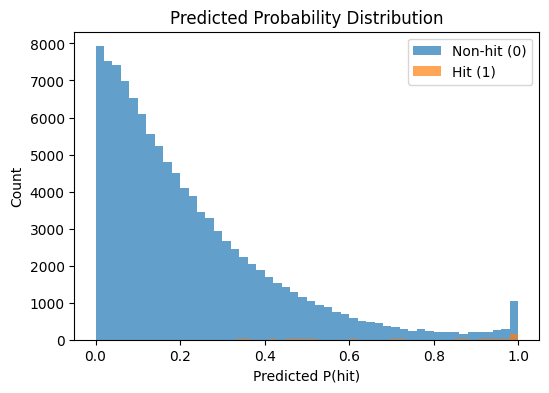

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(y_prob[y_test == 0], bins=50, alpha=0.7, label="Non-hit (0)")
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.7, label="Hit (1)")
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted P(hit)")
plt.ylabel("Count")
plt.legend()
plt.show()

## Decision Threshold Analysis

Because hit songs make up less than 1% of the data, the default 0.5 decision threshold is not appropriate.  
I test several lower thresholds to understand the tradeoff between recall (finding more hits) and precision (avoiding false positives).



In [ ]:
for t in [0.01, 0.02, 0.05, 0.10, 0.20]:
    preds = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    print(f"threshold={t:0.2f} | precision={precision:0.3f} | recall={recall:0.3f} | tp={tp} fp={fp} fn={fn}")


threshold=0.01 | precision=0.004 | recall=1.000 | tp=412 fp=105725 fn=0
threshold=0.02 | precision=0.004 | recall=1.000 | tp=412 fp=101793 fn=0
threshold=0.05 | precision=0.005 | recall=0.998 | tp=411 fp=90425 fn=1
threshold=0.10 | precision=0.006 | recall=0.988 | tp=407 fp=73328 fn=5
threshold=0.20 | precision=0.008 | recall=0.961 | tp=396 fp=47124 fn=16


## Picking Threshold of 0.20
 A threshold of 0.20 was selected to prioritize identifying most potential hits while limiting false positives.

In [ ]:
threshold = 0.20

y_pred_final = (y_prob >= threshold).astype(int)

print("Final threshold:", threshold)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, digits=3))


Final threshold: 0.2

Confusion Matrix:
[[62589 47124]
 [   16   396]]

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.570     0.726    109713
           1      0.008     0.961     0.017       412

    accuracy                          0.572    110125
   macro avg      0.504     0.766     0.371    110125
weighted avg      0.996     0.572     0.724    110125



## Key Drivers of Hit Success

Louder, more danceable songs with higher tempos and larger artist followings are more likely to become hits.

In contrast, longer tracks and songs that are more acoustic, instrumental, or speech-heavy tend to be less likely to break through.  

Overall, the results align well with common characteristics of mainstream popular music.


In [ ]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": log_reg.coef_[0]
}).sort_values("coef", ascending=False)

print("Top positive drivers:")
display(coef_df.head(10))

print("Top negative drivers:")
display(coef_df.tail(10))


Top positive drivers:


,feature,coef
2,loudness,1.181163
12,total_artist_followers,1.179556
0,danceability,0.659182
8,tempo,0.223168
10,key,0.098376
11,mode,-0.047528
5,instrumentalness,-0.088051
4,acousticness,-0.134256
7,valence,-0.163910
3,speechiness,-0.278843


Top negative drivers:


,feature,coef
8,tempo,0.223168
10,key,0.098376
11,mode,-0.047528
5,instrumentalness,-0.088051
4,acousticness,-0.134256
7,valence,-0.163910
3,speechiness,-0.278843
6,liveness,-0.327313
9,duration_ms,-0.651830
1,energy,-0.824266


## Gradient Boosting Model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_imp, y_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

## Classification Threshold

Because hit songs are extremely rare, the classification threshold was chosen to prioritize precision over recall.  




In [ ]:
gb_prob = gb.predict_proba(X_test_imp)[:, 1]

print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, gb_prob))

gb_pred = (gb_prob >= 0.20).astype(int)  # same threshold as logistic

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred, digits=3))

Gradient Boosting ROC-AUC: 0.9488213356135987

Confusion Matrix:
[[109545    168]
 [   303    109]]

Classification Report:
              precision    recall  f1-score   support

           0      0.997     0.998     0.998    109713
           1      0.394     0.265     0.316       412

    accuracy                          0.996    110125
   macro avg      0.695     0.632     0.657    110125
weighted avg      0.995     0.996     0.995    110125



##Model Comparison

Logistic regression was used as a baseline due to its simplicity and interpretability.
Gradient boosting significantly improved ROC-AUC and hit-level precision, indicating that non-linear interactions between audio features and artist popularity play an important role in hit success.

In [ ]:
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, gb_prob))


Logistic Regression ROC-AUC: 0.9244117750646679
Gradient Boosting ROC-AUC: 0.9488213356135987


## Feature Importance (Gradient Boosting)

Feature importance scores show which variables the model relied on most when separating hits from non-hits.  
- Consistent with baseline model!


In [ ]:
gb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": gb.feature_importances_
}).sort_values("importance", ascending=False)

gb_importance.head(10)


,feature,importance
12,total_artist_followers,0.591284
0,danceability,0.068019
8,tempo,0.067787
3,speechiness,0.061703
1,energy,0.044610
6,liveness,0.040049
7,valence,0.029955
9,duration_ms,0.029212
2,loudness,0.019757
4,acousticness,0.019172


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report
)

X_train_use = X_train_imp
X_test_use  = X_test_imp

FIXED_T = 0.20

print(f"Train rows: {X_train_use.shape[0]:,} | Test rows: {X_test_use.shape[0]:,}")
print(f"Train hit rate: {y_train.mean():.4f} | Test hit rate: {y_test.mean():.4f}")

#Only on .25 of the data for speed
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_use, y_train,
    train_size=0.25,
    stratify=y_train,
    random_state=42
)

dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=200,
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train_small, y_train_small)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=200,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_small, y_train_small)

# LR + GB trained on full TRAIN
lr = LogisticRegression(max_iter=2000, class_weight="balanced")
lr.fit(X_train_use, y_train)

gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=200,
    max_depth=3,
    random_state=42
)
gb.fit(X_train_use, y_train)

def f1_best_threshold(prob, y_true):
    p, r, thr = precision_recall_curve(y_true, prob)
    f1 = 2 * (p[:-1] * r[:-1]) / (p[:-1] + r[:-1] + 1e-12)
    return float(thr[np.argmax(f1)])

def eval_on_test(name, model, fixed_t=0.20):
    prob_test = model.predict_proba(X_test_use)[:, 1]

    roc = roc_auc_score(y_test, prob_test)
    pr  = average_precision_score(y_test, prob_test)

    t_f1 = f1_best_threshold(prob_test, y_test)

    print("\n" + "-" * 72)
    print(f"{name} (scored on TEST)")
    print(f"ROC-AUC (TEST): {roc:.4f} | PR-AUC (TEST): {pr:.4f}")

    pred_fixed = (prob_test >= fixed_t).astype(int)
    print(f"\nFixed threshold = {fixed_t:.2f}  (TEST)")
    print(confusion_matrix(y_test, pred_fixed))
    print(classification_report(y_test, pred_fixed, digits=3))

    pred_f1 = (prob_test >= t_f1).astype(int)
    print(f"Max-F1 threshold = {t_f1:.4f}  (TEST)")
    print(confusion_matrix(y_test, pred_f1))
    print(classification_report(y_test, pred_f1, digits=3))

# Model performance (all ROC-AUC/PR-AUC printed here are on TEST)
eval_on_test("Decision Tree", dt, FIXED_T)
eval_on_test("Random Forest", rf, FIXED_T)
eval_on_test("Logistic Regression", lr, FIXED_T)
eval_on_test("Gradient Boosting", gb, FIXED_T)

# Logistic Regression coefficients
feature_names = list(X.columns) if "X" in globals() and hasattr(X, "columns") else [f"x{i}" for i in range(X_train_use.shape[1])]
lr_coef = pd.DataFrame({"feature": feature_names, "coef": lr.coef_.ravel()})
lr_coef["abs_coef"] = lr_coef["coef"].abs()
lr_coef = lr_coef.sort_values("abs_coef", ascending=False).reset_index(drop=True)

print("\n" + "=" * 72)
print("Logistic Regression — largest coefficients (by absolute value)")
print(lr_coef[["feature", "coef"]].head(15).to_string(index=False))

# Decision Tree feature importance
dt_imp = pd.DataFrame({"feature": feature_names, "importance": dt.feature_importances_})
dt_imp = dt_imp.sort_values("importance", ascending=False).reset_index(drop=True)

print("\n" + "=" * 72)
print("Decision Tree — top feature importances")
print(dt_imp.head(15).to_string(index=False))



Train rows: 440,497 | Test rows: 110,125
Train hit rate: 0.0037 | Test hit rate: 0.0037

------------------------------------------------------------------------
Decision Tree (scored on TEST)
ROC-AUC (TEST): 0.8963 | PR-AUC (TEST): 0.0891

Fixed threshold = 0.20  (TEST)
[[96236 13477]
 [   60   352]]
              precision    recall  f1-score   support

           0      0.999     0.877     0.934    109713
           1      0.025     0.854     0.049       412

    accuracy                          0.877    110125
   macro avg      0.512     0.866     0.492    110125
weighted avg      0.996     0.877     0.931    110125

Max-F1 threshold = 0.9783  (TEST)
[[108843    870]
 [   253    159]]
              precision    recall  f1-score   support

           0      0.998     0.992     0.995    109713
           1      0.155     0.386     0.221       412

    accuracy                          0.990    110125
   macro avg      0.576     0.689     0.608    110125
weighted avg      0.995     0

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

def auc_check(name, model):
    p_tr = model.predict_proba(X_train_use)[:, 1]
    p_te = model.predict_proba(X_test_use)[:, 1]

    print(f"{name:<18} "
          f"ROC train {roc_auc_score(y_train, p_tr):.4f} | "
          f"ROC test {roc_auc_score(y_test,  p_te):.4f} | "
          f"PR test {average_precision_score(y_test, p_te):.4f}")

print("\nAUC sanity check (train vs test):")
auc_check("Decision Tree", dt)
auc_check("Random Forest", rf)
auc_check("Logistic Reg", lr)
auc_check("Grad Boost", gb)


AUC sanity check (train vs test):
Decision Tree      ROC train 0.9180 | ROC test 0.8963 | PR test 0.0891
Random Forest      ROC train 0.9590 | ROC test 0.9493 | PR test 0.1564
Logistic Reg       ROC train 0.9165 | ROC test 0.9104 | PR test 0.1001
Grad Boost         ROC train 0.9552 | ROC test 0.9488 | PR test 0.2605


## Quick Model Comparisons

I ran a couple additional models (Decision Tree + Random Forest) mainly as benchmarks.  
To keep runtime reasonable on a large dataset, they’re trained on a stratified sample of the training data, but still evaluated on the full test set.

This gives a fair comparison without spending forever training models that usually don’t beat gradient boosting on this type of problem.


Decision Tree and Random Forest models achieve high recall but flag a very large number of songs as potential hits, resulting in low precision. Logistic Regression serves as a baseline and shows similar behavior, catching most hits but producing many false positives.

Gradient Boosting performs the best overall. It maintains a strong ROC-AUC while flagging far fewer songs and achieving much higher precision. Because of this balance, Gradient Boosting is the most practical model for identifying a manageable set of high-potential songs.



Scoring split -> train n=440,497, holdout n=110,125
Hit rate -> train=0.0037, holdout=0.0037


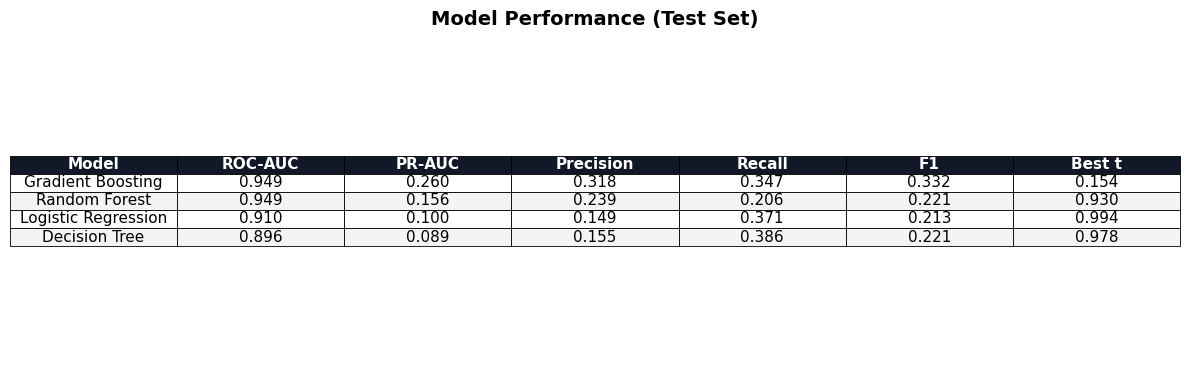

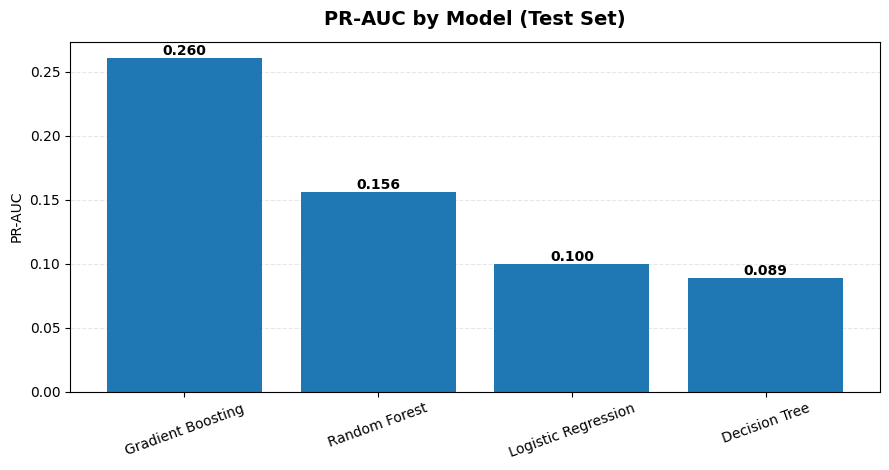

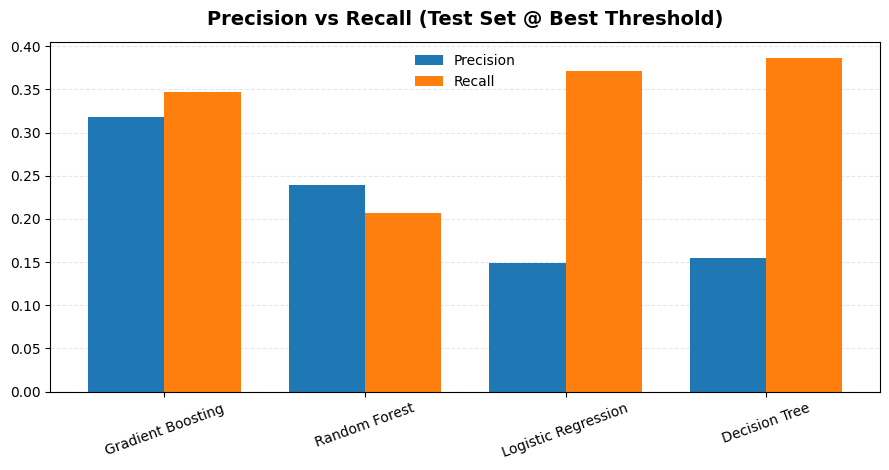

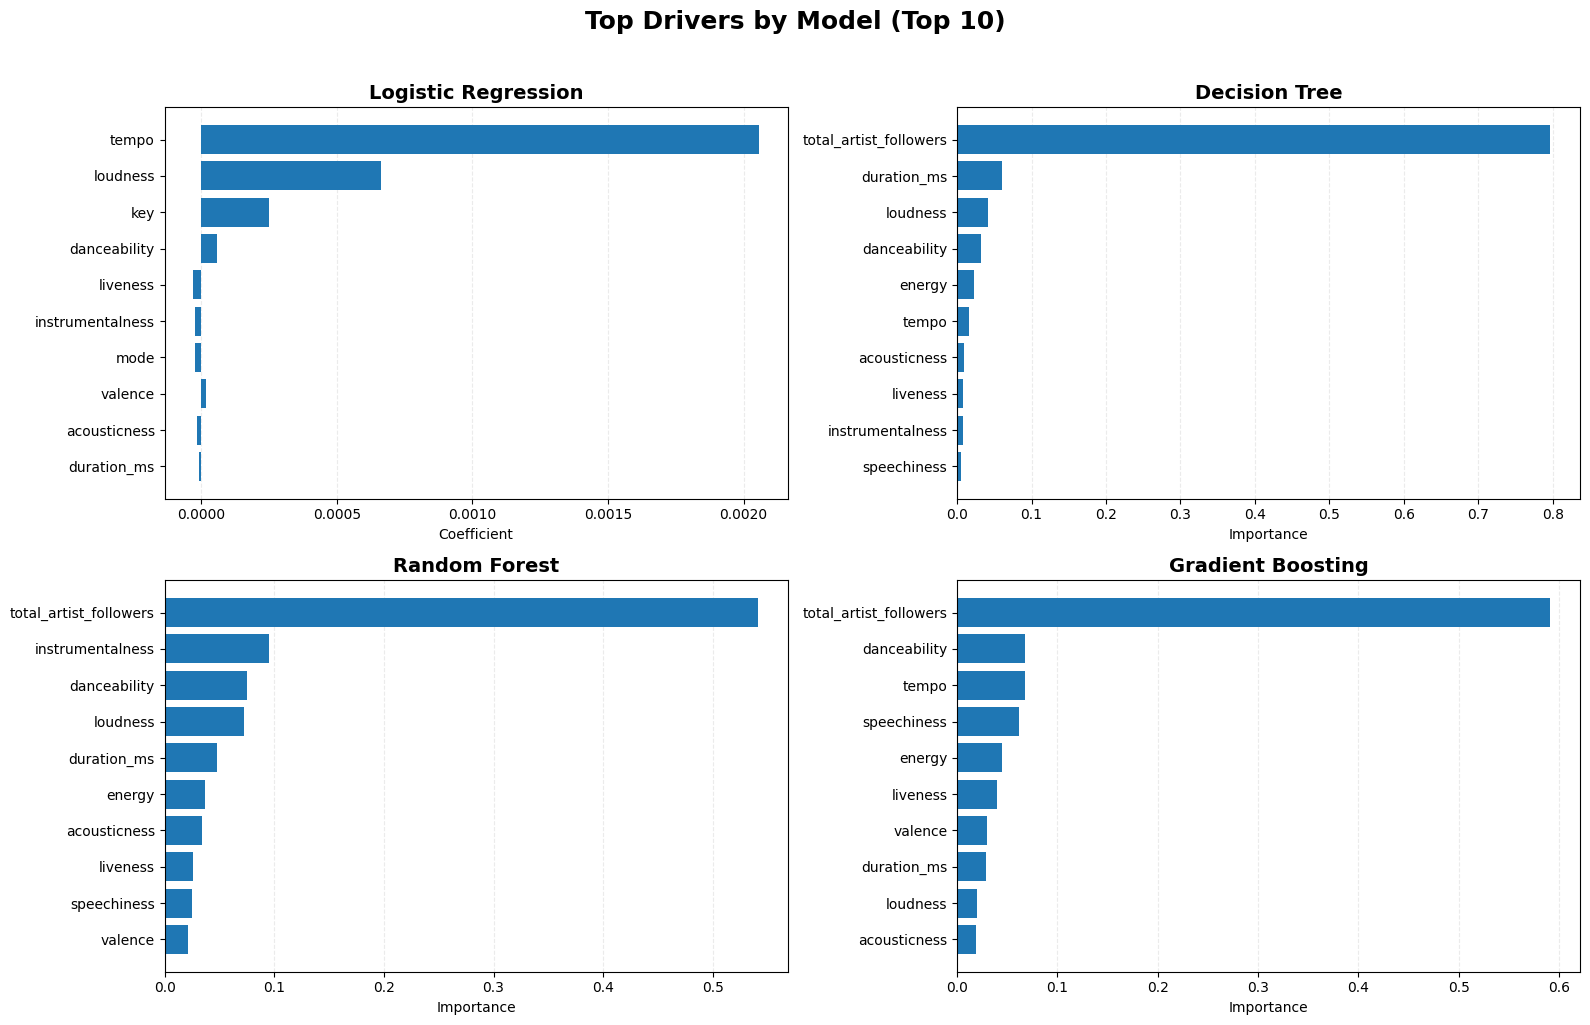

Saved:
 - model_summary_table.png
 - pr_auc_by_model.png
 - precision_vs_recall.png
 - drivers_*.png
 - top_drivers_2x2.png


In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)

Xtr = X_train_use
Xte = X_test_use

print(f"Scoring split -> train n={Xtr.shape[0]:,}, holdout n={Xte.shape[0]:,}")
print(f"Hit rate -> train={y_train.mean():.4f}, holdout={y_test.mean():.4f}")

def best_threshold(prob, y):
    p, r, thr = precision_recall_curve(y, prob)
    f1 = 2 * (p[:-1] * r[:-1]) / (p[:-1] + r[:-1] + 1e-12)
    return float(thr[np.argmax(f1)])

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

rows = []
for name, m in models.items():
    prob = m.predict_proba(Xte)[:, 1]
    t = best_threshold(prob, y_test)
    pred = (prob >= t).astype(int)

    rows.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "Best t": t
    })

df = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False).reset_index(drop=True)

# Table
tbl = df.copy()
for c in ["ROC-AUC","PR-AUC","Precision","Recall","F1","Best t"]:
    tbl[c] = tbl[c].map(lambda x: f"{x:.3f}")

fig, ax = plt.subplots(figsize=(12, 1.6 + 0.55*len(tbl)))
ax.axis("off")

tobj = ax.table(
    cellText=tbl.values,
    colLabels=tbl.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tobj.auto_set_font_size(False)
tobj.set_fontsize(11)

for (r, c), cell in tobj.get_celld().items():
    cell.set_linewidth(0.6)
    if r == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#111827")
    else:
        cell.set_facecolor("#F3F4F6" if r % 2 == 0 else "white")

ax.set_title("Model Performance (Test Set)", fontsize=14, weight="bold", pad=12)
plt.tight_layout()
plt.savefig("model_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()

# PR-AUC
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(df["Model"], df["PR-AUC"])
ax.set_title("PR-AUC by Model (Test Set)", fontsize=14, weight="bold", pad=12)
ax.set_ylabel("PR-AUC")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=20)

for i, v in enumerate(df["PR-AUC"].values):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("pr_auc_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

#Precision vs Recall
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(df))
w = 0.38

ax.bar(x - w/2, df["Precision"], width=w, label="Precision")
ax.bar(x + w/2, df["Recall"],    width=w, label="Recall")

ax.set_title("Precision vs Recall (Test Set @ Best Threshold)", fontsize=14, weight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(df["Model"], rotation=20)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("precision_vs_recall.png", dpi=300, bbox_inches="tight")
plt.show()

drivers = {}

# Logistic Regression coefficients
lr_coef = pd.DataFrame({
    "feature": feature_names,
    "value": lr.coef_.ravel()
})
lr_coef["abs"] = lr_coef["value"].abs()
lr_coef = lr_coef.sort_values("abs", ascending=False).drop(columns="abs").reset_index(drop=True)
drivers["Logistic Regression"] = lr_coef

# Tree-based importances
for nm, m in [("Decision Tree", dt), ("Random Forest", rf), ("Gradient Boosting", gb)]:
    imp = pd.DataFrame({
        "feature": feature_names,
        "value": m.feature_importances_
    }).sort_values("value", ascending=False).reset_index(drop=True)
    drivers[nm] = imp

#Top Driver 2x2 charts
order = ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.ravel()

for ax, nm in zip(axs, order):
    d = drivers[nm].head(10)
    ax.barh(d["feature"][::-1], d["value"][::-1])
    ax.set_title(nm, fontsize=14, weight="bold")
    ax.set_xlabel("Coefficient" if nm == "Logistic Regression" else "Importance")
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

fig.suptitle("Top Drivers by Model (Top 10)", fontsize=18, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig("top_drivers_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(" - model_summary_table.png")
print(" - pr_auc_by_model.png")
print(" - precision_vs_recall.png")
print(" - drivers_*.png")
print(" - top_drivers_2x2.png")

In [ ]:
model_name = "Gradient Boosting"
model_map = {
    "Gradient Boosting": gb,
    "Random Forest": rf,
    "Decision Tree": dt,
    "Logistic Regression": lr
}
m = model_map[model_name]

Xte = X_test_use
yte = y_test
holdout_rows = songs_with_artists.loc[X_test.index].copy()

# probs on test
prob = m.predict_proba(Xte)[:, 1]

# best F1 threshold
p, r, thr = precision_recall_curve(yte, prob)
f1 = 2 * (p[:-1] * r[:-1]) / (p[:-1] + r[:-1] + 1e-12)
t_best = float(thr[np.argmax(f1)])

pred = (prob >= t_best).astype(int)

out = holdout_rows.copy()
out["p_hit"] = prob
out["pred"] = pred
out["actual"] = yte.values

# groups
tp = out[(out["pred"] == 1) & (out["actual"] == 1)].sort_values("p_hit", ascending=False)
fn = out[(out["pred"] == 0) & (out["actual"] == 1)].sort_values("p_hit", ascending=False)
fp = out[(out["pred"] == 1) & (out["actual"] == 0)].sort_values("p_hit", ascending=False)

top_n = 5

show_cols = [c for c in ["name", "artists", "total_artist_followers", "p_hit"] if c in out.columns]

# de-dupeing
dedupe_keys = [c for c in ["name", "artists"] if c in out.columns]
tp_show = tp.drop_duplicates(subset=dedupe_keys) if dedupe_keys else tp.copy()
fn_show = fn.drop_duplicates(subset=dedupe_keys) if dedupe_keys else fn.copy()
fp_show = fp.drop_duplicates(subset=dedupe_keys) if dedupe_keys else fp.copy()

# surprise hits
# low followers among hits

surprise = tp_show.copy()
if "total_artist_followers" in out.columns and len(tp_show) > 0:
    hit_followers = out.loc[out["actual"] == 1, "total_artist_followers"]
    if len(hit_followers) > 0:
        follower_cut = hit_followers.quantile(0.25)  # bottom quartile of HITS
        surprise = tp_show[tp_show["total_artist_followers"] <= follower_cut].sort_values("p_hit", ascending=False)

print(f"{model_name} | test threshold (best F1): {t_best:.4f}")
print(f"TP={len(tp)} | FN={len(fn)} | FP={len(fp)}")
print(f"Showing up to {top_n} unique songs per section")

print("\nCorrectly Predicted Hits")
display(tp_show[show_cols].head(top_n).reset_index(drop=True))

print("\nMissed Hits")
display(fn_show[show_cols].head(top_n).reset_index(drop=True))

print("\nSurprise Hits (low followers, correctly predicted)")
display(surprise[show_cols].head(top_n).reset_index(drop=True))


Gradient Boosting | test threshold (best F1): 0.1536
TP=143 | FN=269 | FP=307
Showing up to 5 unique songs per section

Correctly Predicted Hits


,name,artists,total_artist_followers,p_hit
0,Ferrari,"[""James Hype"", ""Miggy Dela Rosa""]",526658,1.000000
1,In My Mind,"[""Dynoro"", ""Gigi D'Agostino""]",1448191,1.000000
2,NOSTYLIST,"[""Destroy Lonely""]",1747555,0.999977
3,'Til You Can't,"[""Cody Johnson""]",2041002,0.986058
4,NUMB,"[""XXXTENTACION""]",52252497,0.858840



Missed Hits


,name,artists,total_artist_followers,p_hit
0,Ni**as In Paris,"[""JAY-Z"", ""Kanye West""]",42122818,0.146636
1,Stupid Love,"[""Lady Gaga""]",43484481,0.143429
2,FAKE LOVE,"[""BTS""]",81716369,0.142687
3,FRANCHISE (feat. Young Thug & M.I.A.),"[""Travis Scott"", ""Young Thug"", ""M.I.A.""]",56004624,0.138566
4,Love Again,"[""Dua Lipa""]",47259199,0.137295



Surprise Hits (low followers, correctly predicted)


,name,artists,total_artist_followers,p_hit
0,Ferrari,"[""James Hype"", ""Miggy Dela Rosa""]",526658,1.000000
1,In My Mind,"[""Dynoro"", ""Gigi D'Agostino""]",1448191,1.000000
2,NOSTYLIST,"[""Destroy Lonely""]",1747555,0.999977
3,'Til You Can't,"[""Cody Johnson""]",2041002,0.986058
